In [11]:
import pickle

class UltraEnsembleModel:
    """Combines multiple models via majority voting"""

    def __init__(self, models_dict, feature_selector=None):
        self.models = models_dict
        self.selector = feature_selector

    def predict(self, X):
        all_preds = {}

        for name, model in self.models.items():
            if name == 'stacking_selected' and self.selector is not None:
                X_sel = self.selector.transform(X)
                all_preds[name] = model.predict(X_sel)
            else:
                all_preds[name] = model.predict(X)

        # Majority voting
        n_samples = len(X)
        final_preds = []
        for i in range(n_samples):
            votes = [pred[i] for pred in all_preds.values()]
            final_preds.append(max(set(votes), key=votes.count))

        return np.array(final_preds)

    def predict_proba(self, X):
        all_probas = dict()

        for name, model in self.models.items():
            if name == 'stacking_selected' and self.selector is not None:
                X_sel = self.selector.transform(X)
                all_probas[name] = model.predict_proba(X_sel)
            else:
                all_probas[name] = model.predict_proba(X)

        # Average probabilities
        return np.mean(list(all_probas.values()), axis=0), all_probas

with open('best_emotion_model.pkl', 'rb') as f:
    bundle = pickle.load(f)

# Extract components
model = bundle['model']
scaler = bundle['scaler']
class_labels = bundle['class_labels']

In [12]:
import librosa
import numpy as np


def extract_features_enhanced(path):
    """
    Extract 210 features:
    - Original 162 features
    - Delta MFCCs (20)
    - Delta-Delta MFCCs (20)
    - Prosodic features (8)
    """
    data, sr = librosa.load(path, duration=2.5, offset=0.6)
    result = np.array([])
    
    # === ORIGINAL FEATURES (162) ===
    # ZCR (1)
    zcr = np.mean(librosa.feature.zero_crossing_rate(y=data).T, axis=0)
    result = np.hstack((result, zcr))
    
    # Chroma STFT (12)
    stft = np.abs(librosa.stft(data))
    chroma_stft = np.mean(librosa.feature.chroma_stft(S=stft, sr=sr).T, axis=0)
    result = np.hstack((result, chroma_stft))
    
    # MFCC (20)
    mfcc = librosa.feature.mfcc(y=data, sr=sr, n_mfcc=20)
    mfcc_mean = np.mean(mfcc.T, axis=0)
    result = np.hstack((result, mfcc_mean))
    
    # RMS (1)
    rms = np.mean(librosa.feature.rms(y=data).T, axis=0)
    result = np.hstack((result, rms))
    
    # Mel Spectrogram (128)
    mel = np.mean(librosa.feature.melspectrogram(y=data, sr=sr).T, axis=0)
    result = np.hstack((result, mel))
    
    # === NEW: DELTA FEATURES (40) ===
    # Delta MFCC (20) - first derivative
    delta_mfcc = librosa.feature.delta(mfcc)
    delta_mfcc_mean = np.mean(delta_mfcc.T, axis=0)
    result = np.hstack((result, delta_mfcc_mean))
    
    # Delta-Delta MFCC (20) - second derivative
    delta2_mfcc = librosa.feature.delta(mfcc, order=2)
    delta2_mfcc_mean = np.mean(delta2_mfcc.T, axis=0)
    result = np.hstack((result, delta2_mfcc_mean))
    
    # === NEW: PROSODIC FEATURES (8) ===
    # Pitch statistics (5)
    pitches, magnitudes = librosa.piptrack(y=data, sr=sr)
    pitch_values = pitches[pitches > 0]
    
    if len(pitch_values) > 0:
        pitch_mean = np.mean(pitch_values)
        pitch_std = np.std(pitch_values)
        pitch_max = np.max(pitch_values)
        pitch_min = np.min(pitch_values)
        pitch_range = pitch_max - pitch_min
    else:
        pitch_mean = pitch_std = pitch_max = pitch_min = pitch_range = 0
    
    # Energy dynamics (3)
    rms_full = librosa.feature.rms(y=data)[0]
    energy_std = np.std(rms_full)
    energy_slope = np.polyfit(range(len(rms_full)), rms_full, 1)[0] if len(rms_full) > 1 else 0
    energy_range = np.max(rms_full) - np.min(rms_full) if len(rms_full) > 0 else 0
    
    prosodic = np.array([pitch_mean, pitch_std, pitch_range, pitch_max, pitch_min,
                         energy_std, energy_slope, energy_range])
    result = np.hstack((result, prosodic))
    
    return result

In [3]:
import os
import pandas as pd


Crema = "./AudioWAV/"
crema_directory_list = os.listdir(Crema)

file_emotion = []
file_path = []

for file in crema_directory_list:
    if not file.lower().endswith('.wav'):
        continue
    # storing file paths
    file_path.append(Crema + file)
    # storing file emotions
    part=file.split('_')
    if part[2] == 'SAD':
        file_emotion.append('sad')
    elif part[2] == 'ANG':
        file_emotion.append('angry')
    elif part[2] == 'DIS':
        file_emotion.append('disgust')
    elif part[2] == 'FEA':
        file_emotion.append('fear')
    elif part[2] == 'HAP':
        file_emotion.append('happy')
    elif part[2] == 'NEU':
        file_emotion.append('neutral')
    else:
        file_emotion.append('Unknown')
        
# dataframe for emotion of files
emotion_df = pd.DataFrame(file_emotion, columns=['Emotion'])

# dataframe for path of files.
path_df = pd.DataFrame(file_path, columns=['Path'])
Crema_df = pd.concat([emotion_df, path_df], axis=1)
Crema_df = Crema_df[Crema_df['Emotion'] != 'Unknown']
demographics_df = pd.read_csv("VideoDemographics.csv")
actor_genders = []
Crema_df["ActorID"] = Crema_df["Path"].str.extract(pat=r'/(\d{4})_.+\.wav').astype(int)
Crema_df = pd.merge(Crema_df, demographics_df, on="ActorID", how="left")
Crema_df.sample(5)

,Emotion,Path,ActorID,Age,Sex,Race,Ethnicity
4659,neutral,./AudioWAV/1058_DFA_NEU_XX.wav,1058,36,Female,Caucasian,Not Hispanic
1267,neutral,./AudioWAV/1016_IWW_NEU_XX.wav,1016,61,Male,Caucasian,Not Hispanic
5264,disgust,./AudioWAV/1065_ITS_DIS_XX.wav,1065,38,Male,Caucasian,Not Hispanic
2824,happy,./AudioWAV/1035_MTI_HAP_XX.wav,1035,48,Male,Caucasian,Not Hispanic
1848,sad,./AudioWAV/1023_TAI_SAD_XX.wav,1023,22,Male,Caucasian,Not Hispanic


In [4]:
df = pd.read_csv('features_enhanced.csv')[::3]
X = df.drop(columns='labels').values
y = df['labels'].values
X_scaled = scaler.transform(X)

In [13]:
import os
import pandas as pd

Ravdess = "./RAVDESS/"
ravdess_directory_list = os.listdir(Ravdess)

file_emotion = []
file_path = []
for dir in ravdess_directory_list:
    # as their are 20 different actors in our previous directory we need to extract files for each actor.
    actor = os.listdir(Ravdess + dir)
    for file in actor:
        part = file.split('.')[0]
        part = part.split('-')
        # third part in each file represents the emotion associated to that file.
        file_emotion.append(int(part[2]))
        file_path.append(Ravdess + dir + '/' + file)
        
# dataframe for emotion of files
emotion_df = pd.DataFrame(file_emotion, columns=['Emotion'])

# dataframe for path of files.
path_df = pd.DataFrame(file_path, columns=['Path'])
Ravdess_df = pd.concat([emotion_df, path_df], axis=1)

# changing integers to actual emotions.
Ravdess_df['Emotion'] = Ravdess_df['Emotion'].replace({1:'neutral', 2:'calm', 3:'happy', 4:'sad', 5:'angry', 6:'fear', 7:'disgust', 8:'surprise'})
Ravdess_df = Ravdess_df[~Ravdess_df['Emotion'].isin(['calm', 'surprise']) ]
Ravdess_df.sample(5)

,Emotion,Path
216,fear,./RAVDESS/Actor_04/03-01-06-01-01-01-04.wav
1215,happy,./RAVDESS/Actor_21/03-01-03-01-02-02-21.wav
802,sad,./RAVDESS/Actor_14/03-01-04-01-02-01-14.wav
199,happy,./RAVDESS/Actor_04/03-01-03-02-02-02-04.wav
133,happy,./RAVDESS/Actor_03/03-01-03-01-01-02-03.wav


# Test sample

In [15]:
X = np.array([])
y = np.array([])

for idx, row in Ravdess_df.iterrows():
    path = row['Path']
    label = row['Emotion']
    try:
        X = np.vstack((X, extract_features_enhanced(path)))
    except ValueError:
        X = np.hstack((X, extract_features_enhanced(path)))
    y = np.hstack((y, label))
    
X_scaled = scaler.transform(X)
y_pred_proba, all_probas = model.predict_proba(X_scaled)
max_proba = np.max(y_pred_proba, axis=1)
y_pred = [class_labels[i] for i in np.argmax(y_pred_proba, axis=1)]

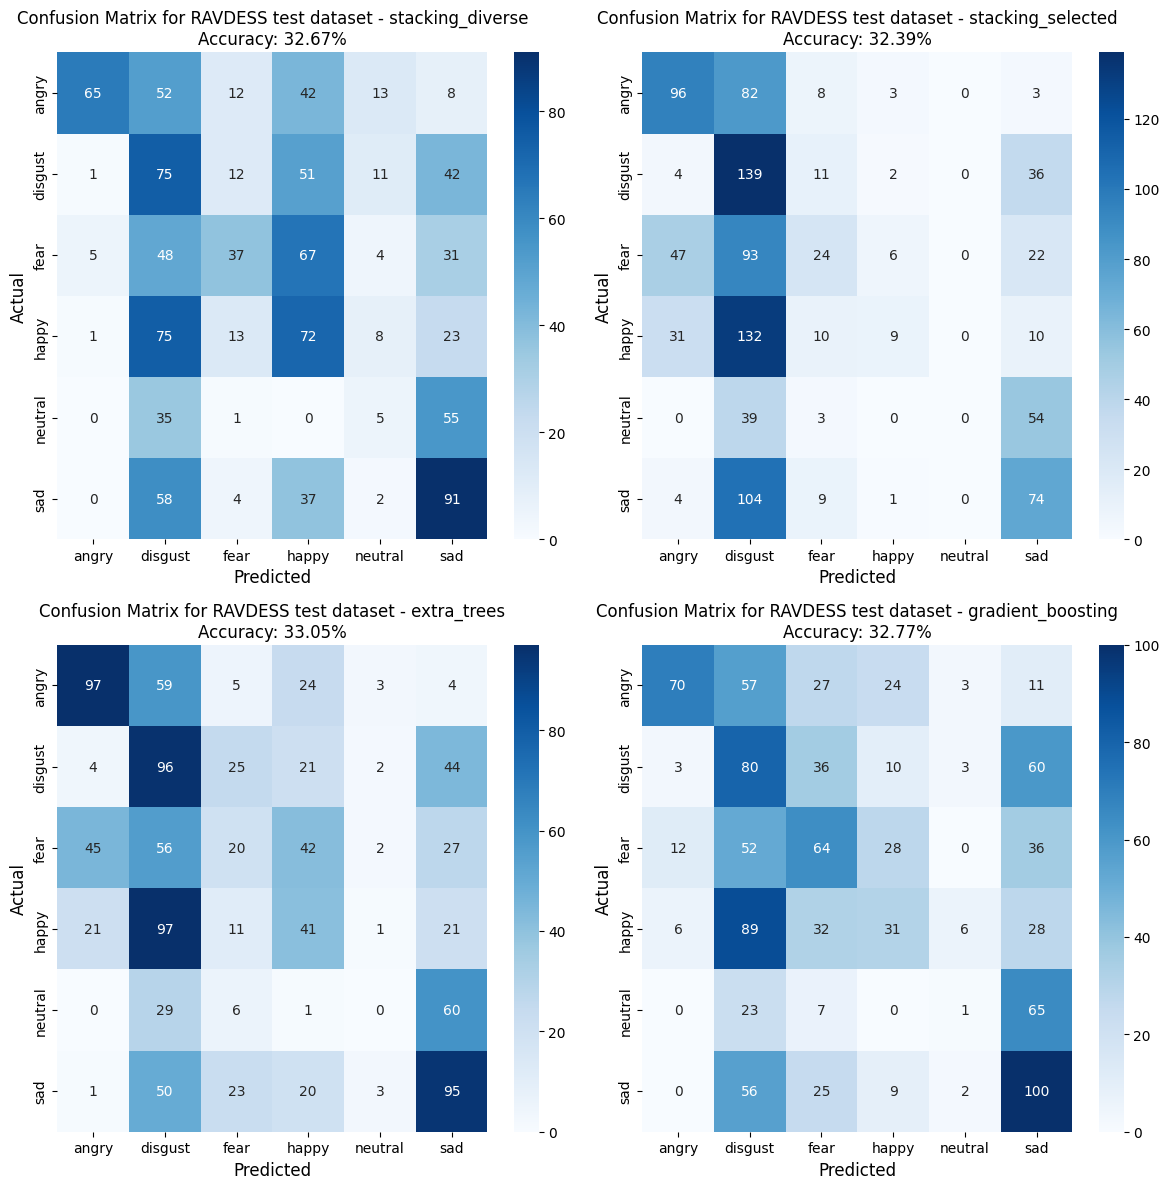

In [18]:
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

plot_idx = 1
plt.figure(figsize=(12, 12))
for key in model.models:
    component_model = model.models[key]
    if key == 'stacking_selected':
        X_sel = model.selector.transform(X_scaled)
        y_pred = component_model.predict(X_sel)
    else:
        y_pred = component_model.predict(X_scaled)
    accuracy = accuracy_score(y, y_pred)
    cm_array = confusion_matrix(y, y_pred)
    
    # Visualize confusion matrix
    plt.subplot(2, 2, plot_idx)
    sns.heatmap(cm_array, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_labels, yticklabels=class_labels)
    plt.title(f'Confusion Matrix for RAVDESS test dataset - {key}\nAccuracy: {accuracy*100:.2f}%')
    plt.xlabel('Predicted', fontsize=12)
    plt.ylabel('Actual', fontsize=12)
    plot_idx += 1

plt.tight_layout()
plt.savefig("RAVDESS_component_models_confusion_matrices.png")
plt.show()


Ultra Ensemble accuracy: 0.3665 (36.65%)
Class labels: ['angry' 'disgust' 'fear' 'happy' 'neutral' 'sad']

Confusion Matrix:
         angry  disgust  fear  happy  neutral  sad
angry       86       80     8     14        0    4
disgust      2      117    14     13        0   46
fear        18       67    40     42        0   25
happy        7      104    16     46        1   18
neutral      0       30     1      0        0   65
sad          0       66     5     23        0   98


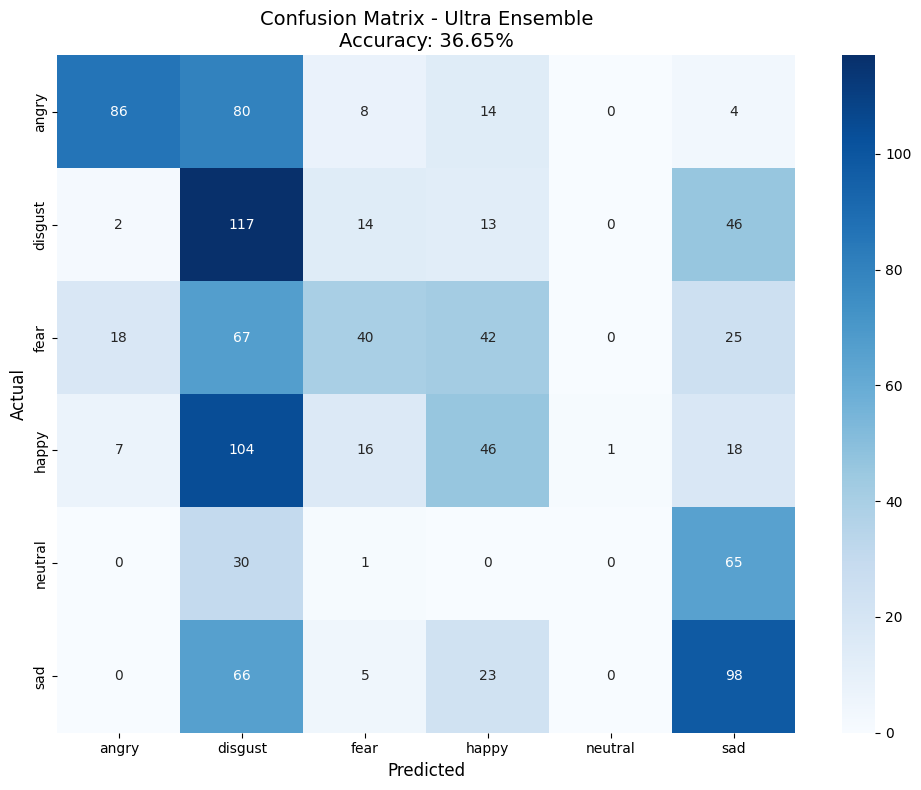

In [26]:
y_pred_proba, all_proba = model.predict_proba(X_scaled)
y_pred_best = [class_labels[i] for i in np.argmax(y_pred_proba, axis=1)]
best_accuracy_final = accuracy_score(y, y_pred_best)

# Generate confusion matrix
cm_array = confusion_matrix(y, y_pred_best)

print(f"\nUltra Ensemble accuracy: {best_accuracy_final:.4f} ({best_accuracy_final*100:.2f}%)")
print(f"Class labels: {class_labels}")

# Display confusion matrix
print("\nConfusion Matrix:")
print(pd.DataFrame(cm_array, index=class_labels, columns=class_labels))

# Visualize confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm_array, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.title(f'Confusion Matrix - Ultra Ensemble\nAccuracy: {best_accuracy_final*100:.2f}%', fontsize=14)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.tight_layout()
plt.savefig("ultra_model_confusion_matrix.png")
plt.show()

In [6]:
sample_label = "DUMMY"
y_pred = ["DUMMY"]
max_proba = 1.0
threshold = 0.5
while sample_label == y_pred[0] and max_proba > threshold:
    sample_idx = np.random.choice(len(Crema_df))
    sample_path = Crema_df['Path'].values[sample_idx]
    sample_label = Crema_df['Emotion'].values[sample_idx]
    X = extract_features_enhanced(sample_path)
    X_scaled = scaler.transform([X])
    y_pred_proba, all_probas = model.predict_proba(X_scaled)
    max_proba = np.max(y_pred_proba, axis=1)
    y_pred = [class_labels[i] for i in np.argmax(y_pred_proba, axis=1)]
    
print(f"Row: {sample_path} -> Prediction: {y_pred[0]}\n")
print(f"total:\n\t{[f"{class_labels[i]}: {y_pred_proba[0][i]:.4f}" for i in range(len(class_labels))]}")
for key in model.models:
    print(f"{key}:\n\t{[f"{class_labels[i]}: {all_probas[key][0][i]:.4f}" for i in range(len(class_labels))]}")

Row: ./AudioWAV/1033_ITS_DIS_XX.wav -> Prediction: disgust

total:
	['angry: 0.0429', 'disgust: 0.3379', 'fear: 0.1741', 'happy: 0.2059', 'neutral: 0.1544', 'sad: 0.0847']
stacking_diverse:
	['angry: 0.0183', 'disgust: 0.4600', 'fear: 0.2352', 'happy: 0.0669', 'neutral: 0.1064', 'sad: 0.1132']
stacking_selected:
	['angry: 0.0120', 'disgust: 0.3154', 'fear: 0.0544', 'happy: 0.4788', 'neutral: 0.1036', 'sad: 0.0358']
extra_trees:
	['angry: 0.0600', 'disgust: 0.3300', 'fear: 0.2000', 'happy: 0.1300', 'neutral: 0.1650', 'sad: 0.1150']
gradient_boosting:
	['angry: 0.0815', 'disgust: 0.2463', 'fear: 0.2068', 'happy: 0.1480', 'neutral: 0.2425', 'sad: 0.0749']


## Confusion Matrices for each Model

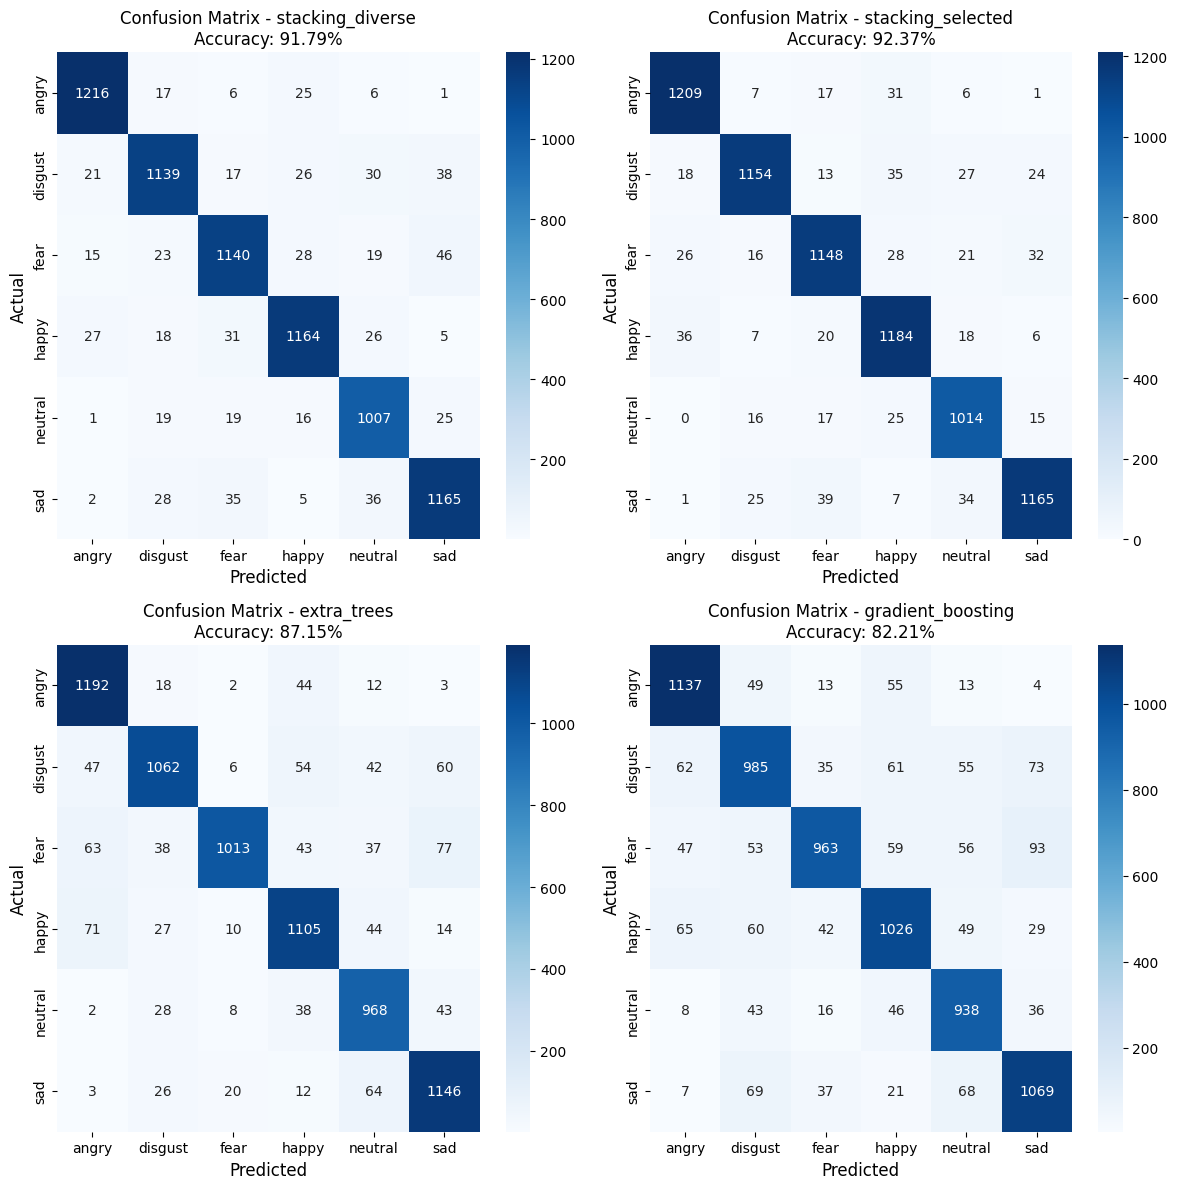

In [266]:
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('features_enhanced.csv')[::3]
X = df.drop(columns='labels').values
y = df['labels'].values
X_scaled = scaler.transform(X)

plot_idx = 1
plt.figure(figsize=(12, 12))
for key in model.models:
    component_model = model.models[key]
    if key == 'stacking_selected':
        X_sel = model.selector.transform(X_scaled)
        y_pred = component_model.predict(X_sel)
    else:
        y_pred = component_model.predict(X_scaled)
    accuracy = accuracy_score(y, y_pred)
    cm_array = confusion_matrix(y, y_pred)
    
    # Visualize confusion matrix
    plt.subplot(2, 2, plot_idx)
    sns.heatmap(cm_array, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_labels, yticklabels=class_labels)
    plt.title(f'Confusion Matrix - {key}\nAccuracy: {accuracy*100:.2f}%')
    plt.xlabel('Predicted', fontsize=12)
    plt.ylabel('Actual', fontsize=12)
    plot_idx += 1

plt.tight_layout()
plt.savefig("component_models_confusion_matrices.png")
plt.show()